In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # flatten 28x28 -> 784
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

100%|██████████| 9.91M/9.91M [00:05<00:00, 1.66MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 728kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


In [3]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)


In [4]:
def train_model(optimizer_name, learning_rate=0.001, epochs=10):
    model = MLP()
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    elif optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)

    loss_history = []

    for epoch in range(epochs):
        total_loss = 0

        for x, y in train_loader:
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)
        print(f"{optimizer_name} | Epoch {epoch+1} | Loss: {avg_loss:.4f}")

    return loss_history


In [5]:
sgd_loss = train_model("SGD")
adam_loss = train_model("Adam")
rms_loss = train_model("RMSprop")

SGD | Epoch 1 | Loss: 2.1556
SGD | Epoch 2 | Loss: 1.6636
SGD | Epoch 3 | Loss: 1.1506
SGD | Epoch 4 | Loss: 0.8510
SGD | Epoch 5 | Loss: 0.6918
SGD | Epoch 6 | Loss: 0.5979
SGD | Epoch 7 | Loss: 0.5371
SGD | Epoch 8 | Loss: 0.4952
SGD | Epoch 9 | Loss: 0.4646
SGD | Epoch 10 | Loss: 0.4413
Adam | Epoch 1 | Loss: 0.3355
Adam | Epoch 2 | Loss: 0.1604
Adam | Epoch 3 | Loss: 0.1160
Adam | Epoch 4 | Loss: 0.0919
Adam | Epoch 5 | Loss: 0.0744
Adam | Epoch 6 | Loss: 0.0638
Adam | Epoch 7 | Loss: 0.0543
Adam | Epoch 8 | Loss: 0.0465
Adam | Epoch 9 | Loss: 0.0401
Adam | Epoch 10 | Loss: 0.0349
RMSprop | Epoch 1 | Loss: 0.2938
RMSprop | Epoch 2 | Loss: 0.1525
RMSprop | Epoch 3 | Loss: 0.1118
RMSprop | Epoch 4 | Loss: 0.0889
RMSprop | Epoch 5 | Loss: 0.0738
RMSprop | Epoch 6 | Loss: 0.0634
RMSprop | Epoch 7 | Loss: 0.0551
RMSprop | Epoch 8 | Loss: 0.0481
RMSprop | Epoch 9 | Loss: 0.0424
RMSprop | Epoch 10 | Loss: 0.0378


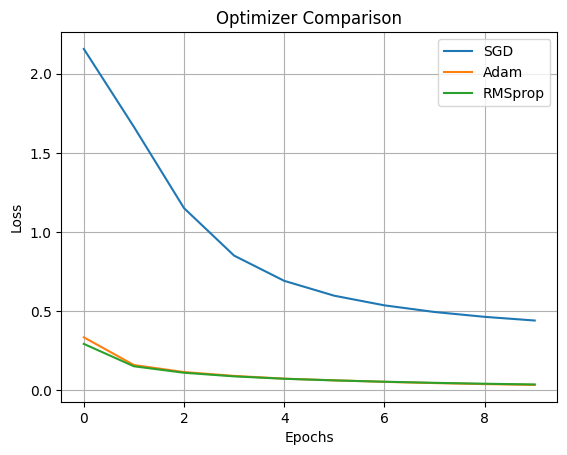

In [6]:
plt.plot(sgd_loss, label="SGD")
plt.plot(adam_loss, label="Adam")
plt.plot(rms_loss, label="RMSprop")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Optimizer Comparison")
plt.legend()
plt.grid()
plt.show()